In [1]:
import torch
from torch import nn
import numpy as np

In [3]:
from pathlib import Path
data_path = Path("../data/")
image_path = data_path / "desert101"

In [4]:
image_path

PosixPath('../data/desert101')

In [5]:
import os

In [6]:
def check_data(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"# of directories: {len(dirnames)} and {len(filenames)} images in {dirpath}")

In [7]:
check_data(image_path)

# of directories: 2 and 1 images in ../data/desert101
# of directories: 4 and 1 images in ../data/desert101/test
# of directories: 0 and 20 images in ../data/desert101/test/cup_cakes
# of directories: 0 and 20 images in ../data/desert101/test/donuts
# of directories: 0 and 20 images in ../data/desert101/test/cannoli
# of directories: 0 and 20 images in ../data/desert101/test/baklava
# of directories: 4 and 1 images in ../data/desert101/train
# of directories: 0 and 80 images in ../data/desert101/train/cup_cakes
# of directories: 0 and 80 images in ../data/desert101/train/donuts
# of directories: 0 and 80 images in ../data/desert101/train/cannoli
# of directories: 0 and 80 images in ../data/desert101/train/baklava


In [8]:
train_dir = image_path / "train"
test_dir = image_path / "test"

In [9]:
train_dir

PosixPath('../data/desert101/train')

In [10]:
test_dir

PosixPath('../data/desert101/test')

In [12]:
from PIL import Image
import random

In [17]:

image_path_list = list(image_path.glob("*/*/*.jpg"))
random_image = random.choice(image_path_list)
img = Image.open(random_image)

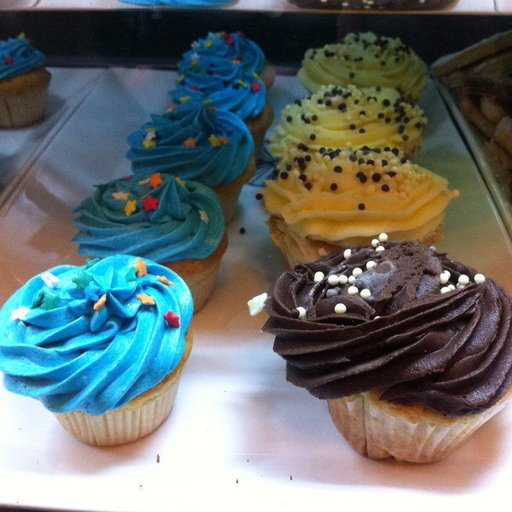

In [18]:
img

In [19]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [20]:
data_transform = transforms.Compose([
    transforms.Resize(size = (64,64)),
    transforms.RandomHorizontalFlip(p=0.4),
    transforms.TrivialAugmentWide(),
    transforms.ToTensor()
])

In [21]:
train_data = datasets.ImageFolder(root=train_dir, transform=data_transform, target_transform=None)
test_data = datasets.ImageFolder(root=test_dir, transform=data_transform, target_transform=None)

In [22]:
train_data

Dataset ImageFolder
    Number of datapoints: 316
    Root location: ../data/desert101/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.4)
               TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               ToTensor()
           )

In [24]:
class_names = train_data.classes

In [25]:
class_names

['baklava', 'cannoli', 'cup_cakes', 'donuts']

In [26]:
len(train_data), len(test_data)

(316, 77)

In [27]:
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

In [28]:
NUM_WORKERS

14

In [29]:
train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, num_workers = NUM_WORKERS, shuffle = True)
test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, num_workers = NUM_WORKERS, shuffle = False)

In [30]:
train_dataloader

In [33]:
train_dataloader.dataset[0][0][0]

tensor([[0.5961, 0.5647, 0.5333,  ..., 0.4706, 0.4392, 0.4392],
        [0.6275, 0.5333, 0.5020,  ..., 0.5020, 0.4392, 0.4706],
        [0.6588, 0.5333, 0.5333,  ..., 0.5647, 0.4392, 0.5333],
        ...,
        [0.9412, 0.9412, 0.9725,  ..., 0.8157, 0.8157, 0.7843],
        [0.9412, 0.9725, 0.9725,  ..., 0.7843, 0.7843, 0.8157],
        [0.9412, 0.9412, 0.9412,  ..., 0.8157, 0.8471, 0.8157]])

In [40]:
class DesertClassifier(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__() 

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 16 * 16, out_features=output_shape)
        )

    def forward(self, x):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))

In [41]:
model_0 = DesertClassifier(
    input_shape=3,
    hidden_units=32,
    output_shape=len(class_names)
)

In [36]:
len(class_names)

4

In [37]:
!pip install torchinfo

In [38]:
from torchinfo import summary

In [42]:
summary(model_0, input_size=[1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
DesertClassifier                         [1, 4]                    --
├─Sequential: 1-1                        [1, 32, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 32, 64, 64]           896
│    └─ReLU: 2-2                         [1, 32, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 32, 64, 64]           9,248
│    └─ReLU: 2-4                         [1, 32, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 32, 32, 32]           --
├─Sequential: 1-2                        [1, 32, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-7                         [1, 32, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-9                         [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 32, 16, 16]           --
├─Seq

In [43]:
def train_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer):
    model.train()
    train_loss = 0.0
    train_acc = 0.0

    for batch, (X,y) in enumerate(dataloader):
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred, dim = 1), dim = 1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)

    return train_loss, train_acc

In [45]:
def test_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module):

    model.eval()
    test_loss = 0.0
    test_acc = 0.0

    with torch.inference_mode():
        for batch, (X,y) in enumerate(dataloader):
            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            test_pred_labels = test_pred_logits.argmax(dim =1)
            test_acc += (test_pred_labels == y).sum().item() / len(test_pred_labels)
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [48]:
def model_train(model: torch.nn.Module, 
                train_dataloader: torch.utils.data.DataLoader,
                test_dataloader: torch.utils.data.DataLoader,
                optimizer: torch.optim.Optimizer,
                loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),               
                epochs: int = 10):
    results = {
        "train_loss" : [],
        "train_acc": [],
        "test_loss": [],
        "test_acc":[]
    }
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model= model, dataloader = train_dataloader, loss_fn=loss_fn, optimizer=optimizer)
        test_loss, test_acc = test_step(model= model, dataloader = test_dataloader, loss_fn=loss_fn)

        print(f"Epoch: {epoch}, Train Acc: {train_acc}, Train Loss: {train_loss}, Test Acc: {test_acc}, Test Loss{test_loss}")
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss
        results["train_acc"].append(train_acc.item()) if isinstance(train_acc, torch.Tensor) else train_acc
        results["test_loss"].append(test_loss.item()) if isinstance(test_loss, torch.Tensor) else train_loss
        results["test_acc"].append(test_acc.item()) if isinstance(train_loss, torch.Tensor) else train_loss
    return results